In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
df = pd.read_csv('Warehouse_and_Retail_Sales.csv')

In [3]:
df.head()

,YEAR,MONTH,SUPPLIER,ITEM CODE,ITEM DESCRIPTION,ITEM TYPE,RETAIL SALES,RETAIL TRANSFERS,WAREHOUSE SALES
0,2020,1,REPUBLIC NATIONAL DISTRIBUTING CO,100009,BOOTLEG RED - 750ML,WINE,0.00,0.0,2.0
1,2020,1,PWSWN INC,100024,MOMENT DE PLAISIR - 750ML,WINE,0.00,1.0,4.0
2,2020,1,RELIABLE CHURCHILL LLLP,1001,S SMITH ORGANIC PEAR CIDER - 18.7OZ,BEER,0.00,0.0,1.0
3,2020,1,LANTERNA DISTRIBUTORS INC,100145,SCHLINK HAUS KABINETT - 750ML,WINE,0.00,0.0,1.0
4,2020,1,DIONYSOS IMPORTS INC,100293,SANTORINI GAVALA WHITE - 750ML,WINE,0.82,0.0,0.0


In [4]:
print(df.shape)
print(df.dtypes)
print(df.isnull().sum())
print(df.describe())

(307645, 9)
YEAR                  int64
MONTH                 int64
SUPPLIER                str
ITEM CODE               str
ITEM DESCRIPTION        str
ITEM TYPE               str
RETAIL SALES        float64
RETAIL TRANSFERS    float64
WAREHOUSE SALES     float64
dtype: object
YEAR                  0
MONTH                 0
SUPPLIER            167
ITEM CODE             0
ITEM DESCRIPTION      0
ITEM TYPE             1
RETAIL SALES          3
RETAIL TRANSFERS      0
WAREHOUSE SALES       0
dtype: int64
                YEAR          MONTH   RETAIL SALES  RETAIL TRANSFERS  \
count  307645.000000  307645.000000  307642.000000     307645.000000   
mean     2018.438525       6.423862       7.024071          6.936465   
std         1.083061       3.461812      30.986238         30.237195   
min      2017.000000       1.000000      -6.490000        -38.490000   
25%      2017.000000       3.000000       0.000000          0.000000   
50%      2019.000000       7.000000       0.320000          0

In [5]:
df['Date'] = pd.to_datetime(df['YEAR'].astype(str) + '-' + df['MONTH'].astype(str) + '-01')
cols = ['Date'] + [col for col in df.columns if col not in ['Date', 'YEAR', 'MONTH']]
df = df[cols]
df.head()

,Date,SUPPLIER,ITEM CODE,ITEM DESCRIPTION,ITEM TYPE,RETAIL SALES,RETAIL TRANSFERS,WAREHOUSE SALES
0,2020-01-01,REPUBLIC NATIONAL DISTRIBUTING CO,100009,BOOTLEG RED - 750ML,WINE,0.00,0.0,2.0
1,2020-01-01,PWSWN INC,100024,MOMENT DE PLAISIR - 750ML,WINE,0.00,1.0,4.0
2,2020-01-01,RELIABLE CHURCHILL LLLP,1001,S SMITH ORGANIC PEAR CIDER - 18.7OZ,BEER,0.00,0.0,1.0
3,2020-01-01,LANTERNA DISTRIBUTORS INC,100145,SCHLINK HAUS KABINETT - 750ML,WINE,0.00,0.0,1.0
4,2020-01-01,DIONYSOS IMPORTS INC,100293,SANTORINI GAVALA WHITE - 750ML,WINE,0.82,0.0,0.0


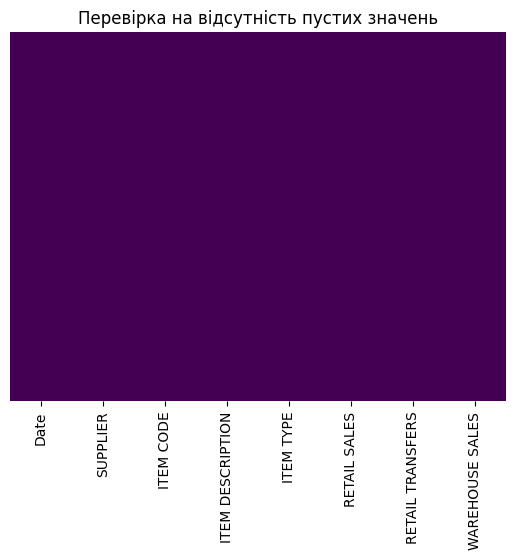

In [6]:
sns.heatmap(df.isnull(), yticklabels=False, cbar=False, cmap='viridis')
plt.title("Перевірка на відсутність пустих значень")
plt.show()

In [7]:
print(df['ITEM TYPE'].unique())

print(df['ITEM TYPE'].value_counts())

<StringArray>
[        'WINE',         'BEER',       'LIQUOR', 'STR_SUPPLIES',
         'KEGS',          'REF',      'DUNNAGE',  'NON-ALCOHOL',
            nan]
Length: 9, dtype: str
ITEM TYPE
WINE            187640
LIQUOR           64910
BEER             42413
KEGS             10146
NON-ALCOHOL       1908
STR_SUPPLIES       405
REF                127
DUNNAGE             95
Name: count, dtype: int64


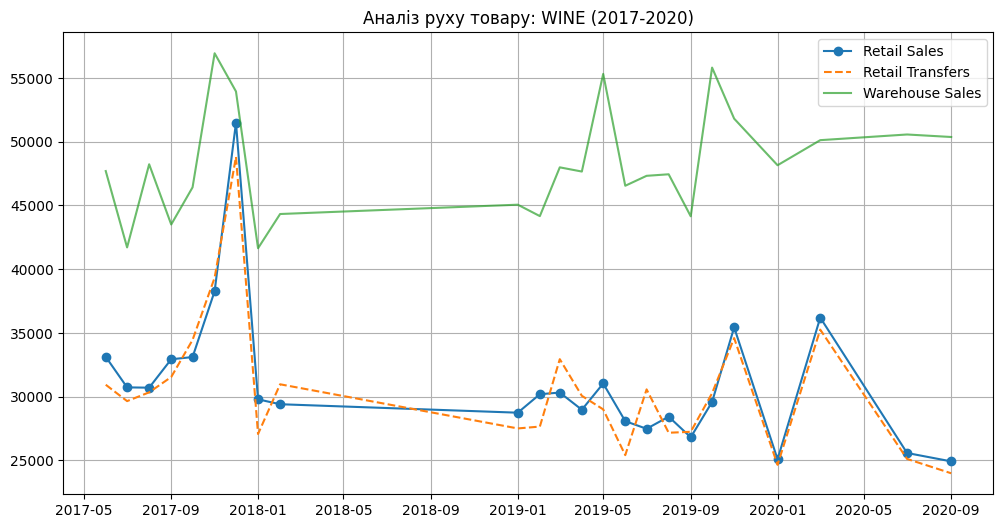

In [8]:
df_wine = df.copy()
wine_data = df_wine[df_wine['ITEM TYPE'] == 'WINE'].groupby('Date')[['RETAIL SALES', 'RETAIL TRANSFERS', 'WAREHOUSE SALES']].sum()

plt.figure(figsize=(12, 6))
plt.plot(wine_data.index, wine_data['RETAIL SALES'], label='Retail Sales', marker='o')
plt.plot(wine_data.index, wine_data['RETAIL TRANSFERS'], label='Retail Transfers', linestyle='--')
plt.plot(wine_data.index, wine_data['WAREHOUSE SALES'], label='Warehouse Sales', alpha=0.7)

plt.title('Аналіз руху товару: WINE (2017-2020)')
plt.legend()
plt.grid(True)
plt.show()

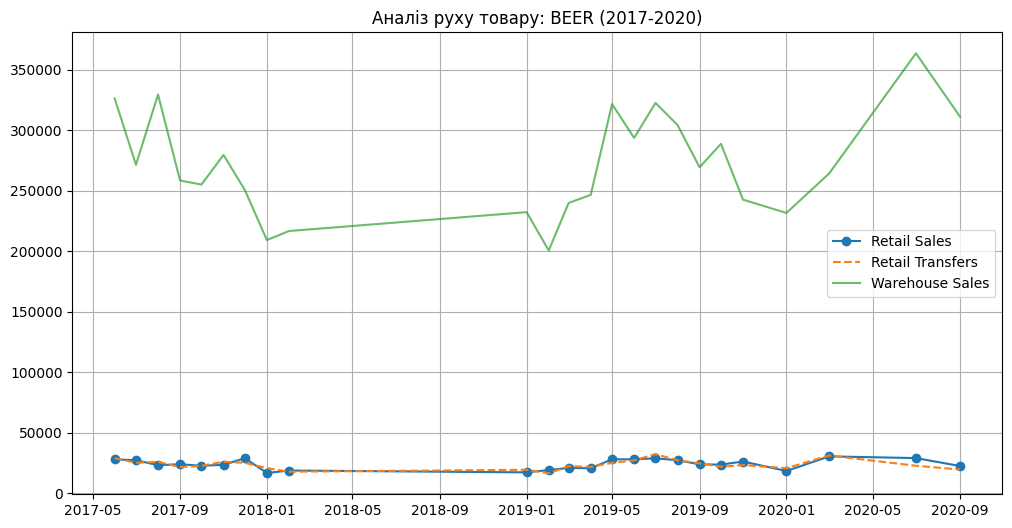

In [9]:
df_beer = df.copy()
beer_data = df_beer[df_beer['ITEM TYPE'] == 'BEER'].groupby('Date')[['RETAIL SALES', 'RETAIL TRANSFERS', 'WAREHOUSE SALES']].sum()

plt.figure(figsize=(12, 6))
plt.plot(beer_data.index, beer_data['RETAIL SALES'], label='Retail Sales', marker='o')
plt.plot(beer_data.index, beer_data['RETAIL TRANSFERS'], label='Retail Transfers', linestyle='--')
plt.plot(beer_data.index, beer_data['WAREHOUSE SALES'], label='Warehouse Sales', alpha=0.7)

plt.title('Аналіз руху товару: BEER (2017-2020)')
plt.legend()
plt.grid(True)
plt.show()

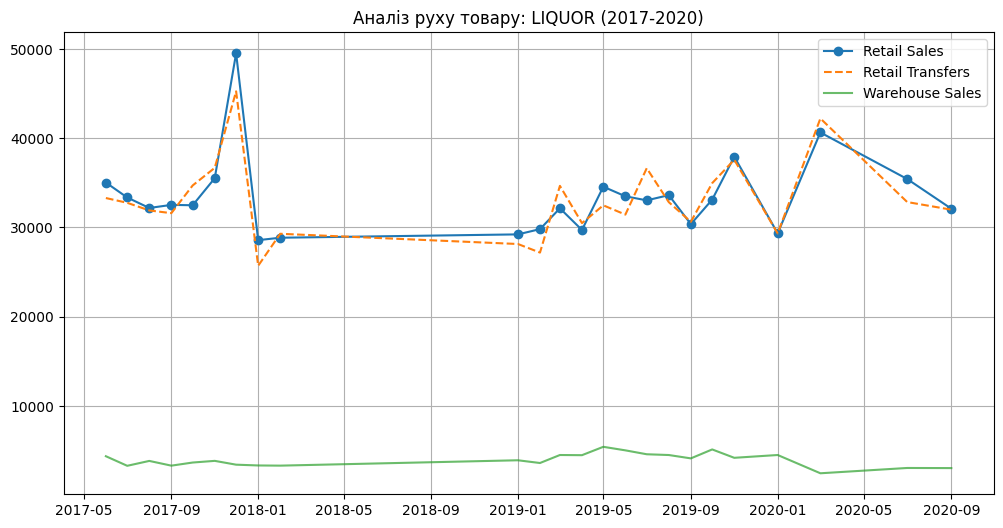

In [10]:
df_liquor = df.copy()
liquour_data = df_liquor[df_liquor['ITEM TYPE'] == 'LIQUOR'].groupby('Date')[['RETAIL SALES', 'RETAIL TRANSFERS', 'WAREHOUSE SALES']].sum()

plt.figure(figsize=(12, 6))
plt.plot(liquour_data.index, liquour_data['RETAIL SALES'], label='Retail Sales', marker='o')
plt.plot(liquour_data.index, liquour_data['RETAIL TRANSFERS'], label='Retail Transfers', linestyle='--')
plt.plot(liquour_data.index, liquour_data['WAREHOUSE SALES'], label='Warehouse Sales', alpha=0.7)

plt.title('Аналіз руху товару: LIQUOR (2017-2020)')
plt.legend()
plt.grid(True)
plt.show()

In [11]:
df_bad_suppliers = df.copy()
bad_suppliers = df.groupby(['SUPPLIER', 'ITEM DESCRIPTION'])[['RETAIL SALES', 'RETAIL TRANSFERS', 'WAREHOUSE SALES']].min()

top_minus_warehouse = bad_suppliers.sort_values(by='WAREHOUSE SALES').head(10)
print("Топ-10 найбільших 'мінусів' (повернень) по складу:")
print(top_minus_warehouse)


Топ-10 найбільших 'мінусів' (повернень) по складу:
                                                                       RETAIL SALES  \
SUPPLIER                  ITEM DESCRIPTION                                            
ANHEUSER BUSCH INC        EMPTY 1/2 KEG (30.00)                                 0.0   
PREMIUM DISTRIBUTORS INC  EMPTY 1/2 KEG (30.00)                                 0.0   
ANHEUSER BUSCH INC        EMPTY 1/6 KEG (30.00)                                 0.0   
                          EMPTY 1/4 KEG (30.00)                                 0.0   
                          BUD SUMMER CAMO ALUMINUM BTL 16.0Z 3/8 PK             0.0   
                          MICHELOB ULTRA 160Z. ALUMIMUN GOLF 24 PK NR           0.0   
HEINEKEN USA              HEINEKEN 0.0  1/15 MIX CAN                            8.0   
ANHEUSER BUSCH INC        BUD LIGHT LIME 24/16 CAL NR 3/8PK                     0.0   
KATCEF BROTHERS INC       DEVILS BACKBONE VIENNA LAGER 24PK 16.0Z CAN          

In [12]:
top_minus_retail = bad_suppliers.sort_values(by='RETAIL TRANSFERS').head(10)
print("Топ-10 найбільших 'мінусів' (повернень) по внутрішніх переміщеннях:")
print(top_minus_retail)

Топ-10 найбільших 'мінусів' (повернень) по внутрішніх переміщеннях:
                                                                     RETAIL SALES  \
SUPPLIER                          ITEM DESCRIPTION                                  
REPUBLIC NATIONAL DISTRIBUTING CO SEACRETS RUM - SPICED - 750ML              0.00   
                                  SEACRETS VODKA - 750ML                     0.00   
ANHEUSER BUSCH INC                NATURAL LIGHT NATURDAYS 18PK CAN           0.00   
REPUBLIC NATIONAL DISTRIBUTING CO SEACRETS WHITE RUM - 750ML                 0.00   
BACARDI USA INC                   GREY GOOSE VODKA - 50ML                    0.29   
REPUBLIC NATIONAL DISTRIBUTING CO SEACRETS GIN - 750ML                       0.00   
LEGENDS LTD                       ROCK CREEK WHITE WHISKEY - 750ML           0.34   
ANHEUSER BUSCH INC                GOLDEN ROAD WOLF PUP 2/15PK CAN            0.00   
BUCK DISTRIBUTING COMPANY INC     BELLS OFFICIAL 4/6 CANS                    2.00 

In [13]:
top_minus_retail_sales = bad_suppliers.sort_values(by='RETAIL SALES').head(10)
print("Топ-10 найбільших 'мінусів' (повернень) по роздрібній торгівлі:")
print(top_minus_retail_sales)

Топ-10 найбільших 'мінусів' (повернень) по роздрібній торгівлі:
                                                                            RETAIL SALES  \
SUPPLIER                             ITEM DESCRIPTION                                      
KYSELA PERE ET FILS LTD              KEERMONT RED BLEND '12                        -6.49   
DIAGEO NORTH AMERICA INC             CROWN ROYAL XTRA RARE 6/CS - 750ML            -2.47   
JACKSON FAMILY ENTERPRISES INC       K JACKSON AVANT RED BLEND - 750ML             -2.00   
HEAVEN HILL DISTILLERIES INC         PARKERS HERITAGE COLLECTION  - 750ML          -1.99   
A VINTNERS SELECTIONS                STONEWALL RUM - 750ML                         -1.84   
PATERNO IMPORTS LTD                  SANFORD SANTA RITA HILLS CHARD -750ML         -1.49   
OPICI FAMILY DISTRIBUTING OF MD      DRUNKEN SAILOR SPICED RUM - 750ML             -1.17   
THE COUNTRY VINTNER, LLC DBA WINEBOW DOM DE TRIENNES ROSE - 750ML                  -1.00   
A VINTNERS SELEC

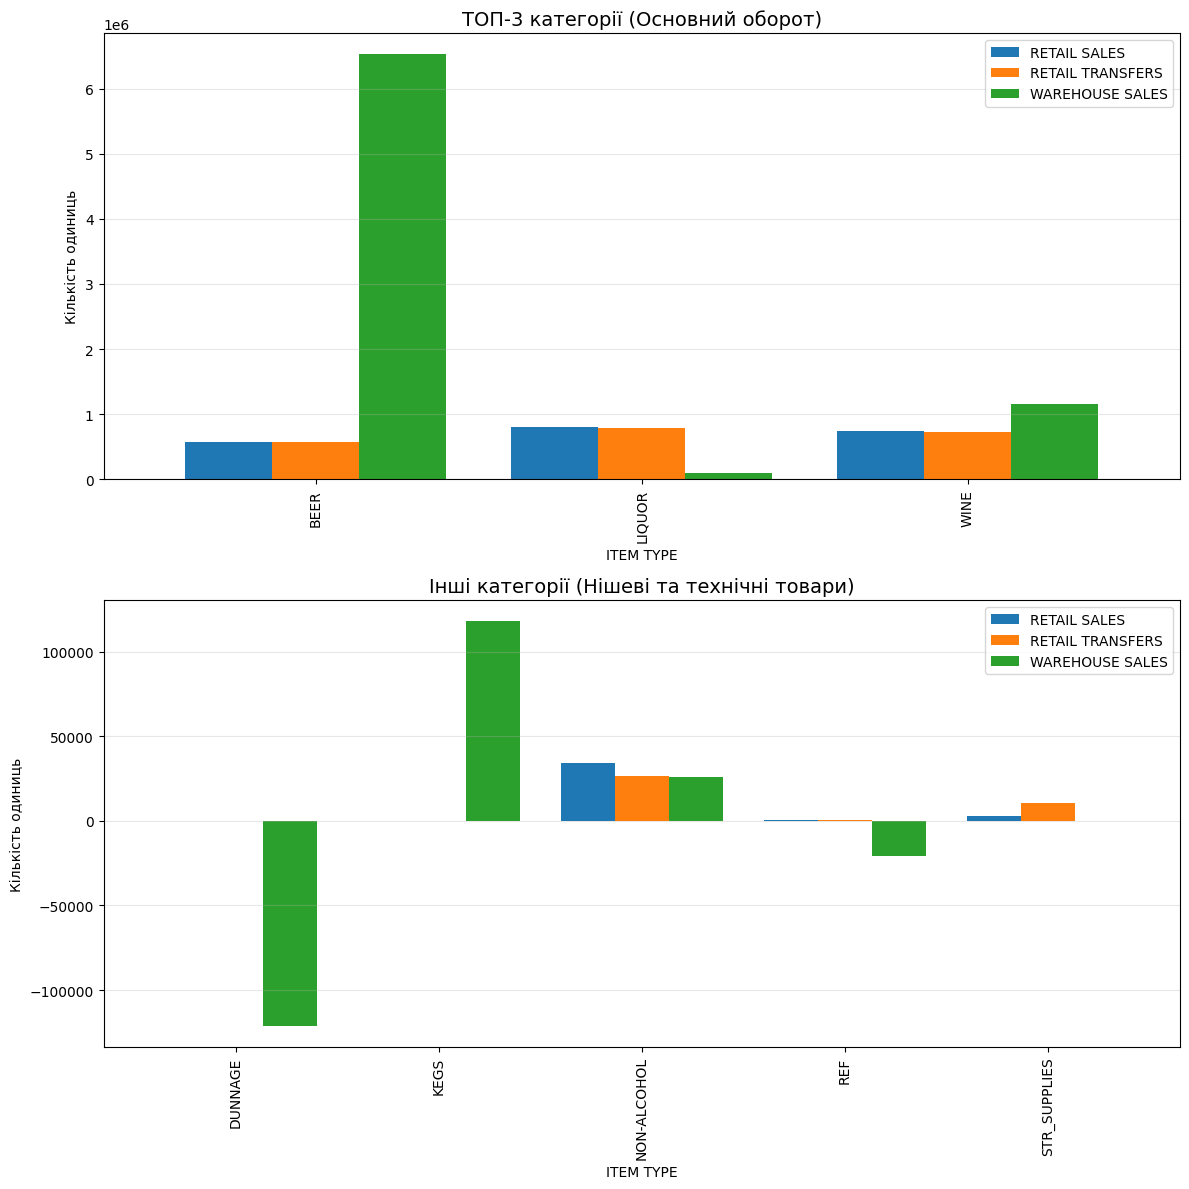

In [14]:
df_category_totals = df.copy()

category_totals = df_category_totals.groupby('ITEM TYPE')[['RETAIL SALES', 'RETAIL TRANSFERS', 'WAREHOUSE SALES']].sum()

top_categories = ['WINE', 'LIQUOR', 'BEER']
df_top = category_totals.loc[category_totals.index.isin(top_categories)]
df_others = category_totals.loc[~category_totals.index.isin(top_categories)]

import matplotlib.pyplot as plt

fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(12, 12))

df_top.plot(kind='bar', ax=ax1, width=0.8)
ax1.set_title('ТОП-3 категорії (Основний оборот)', fontsize=14)
ax1.set_ylabel('Кількість одиниць')
ax1.grid(axis='y', alpha=0.3)

df_others.plot(kind='bar', ax=ax2, width=0.8)
ax2.set_title('Інші категорії (Нішеві та технічні товари)', fontsize=14)
ax2.set_ylabel('Кількість одиниць')
ax2.grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.show()

In [15]:
df_empty_kegs_return = df.copy()
empty_kegs_return = df_empty_kegs_return[df_empty_kegs_return['ITEM DESCRIPTION'].str.contains('EMPTY', na=False)]['WAREHOUSE SALES'].sum()

full_kegs_out = df[df['ITEM TYPE'] == 'KEGS']['WAREHOUSE SALES'].sum()

print(f"Поїхало повних кег (обсяг): {full_kegs_out}")
print(f"Повернулося порожніх (обсяг): {empty_kegs_return}")
print(f"Баланс: {full_kegs_out + empty_kegs_return}")

Поїхало повних кег (обсяг): 118431.0
Повернулося порожніх (обсяг): -121454.0
Баланс: -3023.0


In [16]:
df_top_5 = df.copy()
top_5_suppliers = df_top_5.groupby('SUPPLIER')['WAREHOUSE SALES'].sum().sort_values(ascending=False).head(5).index.tolist()

print("Топ 'велика п'ятірка':")
for i, s in enumerate(top_5_suppliers, 1):
    print(f"{i}. {s}")

Топ 'велика п'ятірка':
1. CROWN IMPORTS
2. MILLER BREWING COMPANY
3. ANHEUSER BUSCH INC
4. HEINEKEN USA
5. E & J GALLO WINERY


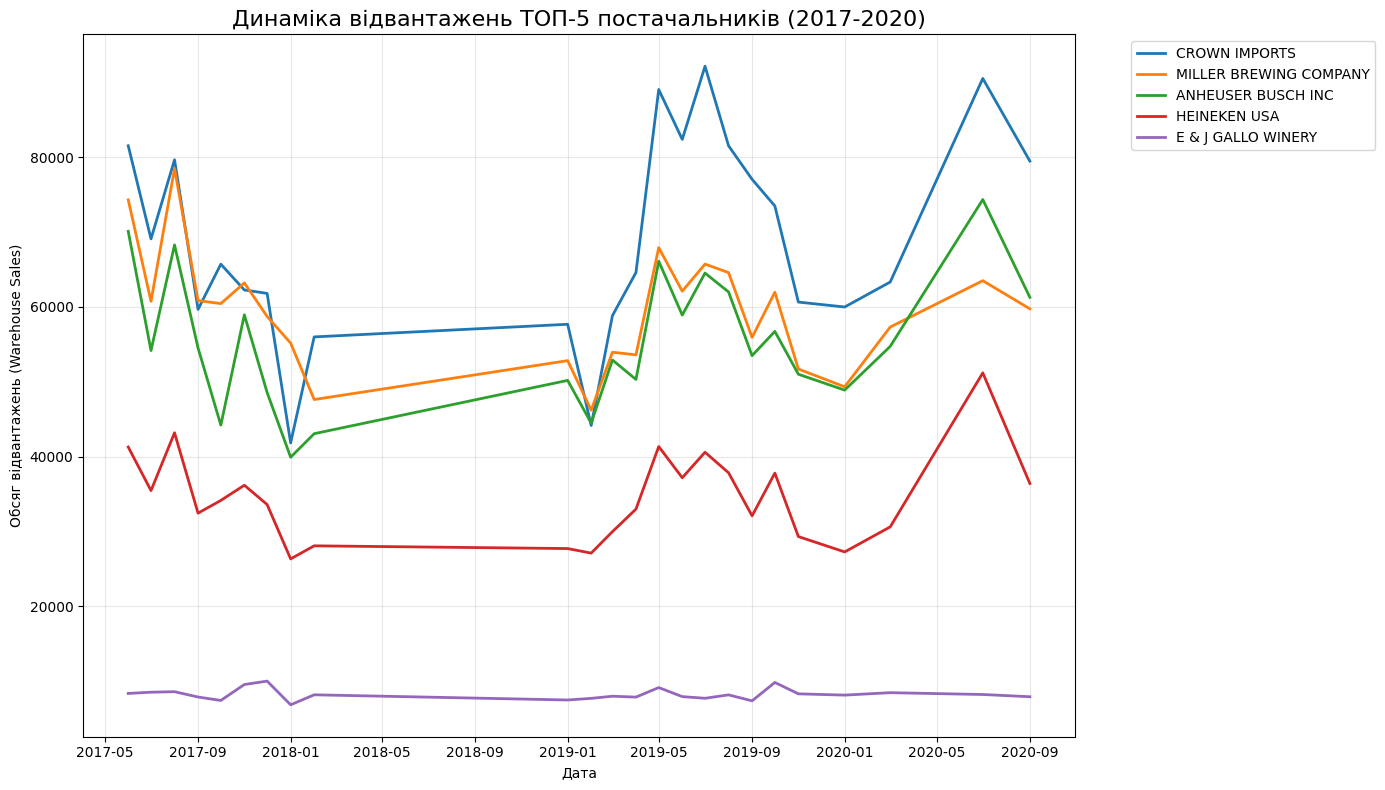

In [17]:
plt.figure(figsize=(14, 8))

for supplier in top_5_suppliers:
    supplier_data = df[df['SUPPLIER'] == supplier].groupby('Date')['WAREHOUSE SALES'].sum()
    plt.plot(supplier_data.index, supplier_data, label=supplier, linewidth=2)

plt.title('Динаміка відвантажень ТОП-5 постачальників (2017-2020)', fontsize=16)
plt.xlabel('Дата')
plt.ylabel('Обсяг відвантажень (Warehouse Sales)')
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

In [18]:
check_minus = df[df['SUPPLIER'].isin(top_5_suppliers)].groupby('SUPPLIER')[['WAREHOUSE SALES', 'RETAIL TRANSFERS']].min()

print("Чи є у лідерів від'ємні значення?")
print(check_minus)

Чи є у лідерів від'ємні значення?
                        WAREHOUSE SALES  RETAIL TRANSFERS
SUPPLIER                                                 
ANHEUSER BUSCH INC             -4996.00            -23.00
CROWN IMPORTS                      0.00              0.00
E & J GALLO WINERY               -17.17             -8.67
HEINEKEN USA                     -99.00             -2.00
MILLER BREWING COMPANY            -3.00             -5.00


In [19]:
df_supplier_volumes = df.copy()
supplier_volumes = df.groupby('SUPPLIER')['WAREHOUSE SALES'].sum().sort_values(ascending=False).head(5)
top_5_suppliers_names = supplier_volumes.index.tolist()

print(f"{'№':<3} | {'Постачальник':<35} | {'Що продають':<15} | {'Загальний обсяг':<15}")
print("-" * 75)

for i, (name, volume) in enumerate(supplier_volumes.items(), 1):
    main_item = df[df['SUPPLIER'] == name]['ITEM TYPE'].mode()[0]
    
    print(f"{i:<3} | {name:<35} | {main_item:<15} | {volume:<15.2f}")

№   | Постачальник                        | Що продають     | Загальний обсяг
---------------------------------------------------------------------------
1   | CROWN IMPORTS                       | BEER            | 1651871.51     
2   | MILLER BREWING COMPANY              | BEER            | 1425428.71     
3   | ANHEUSER BUSCH INC                  | BEER            | 1331170.84     
4   | HEINEKEN USA                        | BEER            | 829796.46      
5   | E & J GALLO WINERY                  | WINE            | 197463.78      
